In [1]:
# ==============================================================================
# IMPORTATION DES BIBLIOTHÈQUES
# ==============================================================================

# --- Système et Gestion des Fichiers ---
import os
import sys
import glob
import tempfile
import warnings
import joblib

# --- Manipulation de Données et Analyse Spatiale ---
import numpy as np
import pandas as pd
import geopandas as gpd

# --- Traitement Géospatial et SIG (GDAL/OGR) ---
from osgeo import gdal, ogr, osr

# --- Apprentissage Automatique (Machine Learning) ---
from sklearn.model_selection import (
    GridSearchCV, 
    train_test_split, 
    StratifiedKFold, 
    GroupKFold
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score, 
    cohen_kappa_score
)

# --- Visualisation de Données et Cartographie ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from IPython.display import display

# --- Bibliothèques Personnalisées (sigmaLib - Environnement Onyxia) ---
sys.path.append('/home/onyxia/work')
from libsigma import classification as cla
from libsigma import read_and_write as rw
from libsigma import plots


# Projet Final : Télédétection Approfondie

**Master 2 SIGMA | ENSAT 3A Agrogéomatique** 

**Année Universitaire : 2025-2026** 

**Enseignant : Marc Lang**

**Auteur: Thiago Gama De Lima**

---

## Introduction

Ce notebook constitue le rapport final du module **Télédétection : approfondissement**. L'objectif principal est d'étudier la dynamique des strates végétales, et plus particulièrement de caractériser les **landes** (famille des *Éricacées*) à l'aide de séries temporelles d'images satellitaires Sentinel-2.

Le projet repose sur une chaîne de traitement complète allant de la préparation des données à la production d'une carte d'occupation du sol par classification supervisée, en passant par le calcul d'indices de phénologie spécifiques comme le **NARI** (*Normalized Anthocyanin Reflectance Index*).

### Informations de l'Étudiant et Attribution

Conformément à la répartition des sites d'étude, ce travail se concentre exclusivement sur les données suivantes :

| Nom | Prénom | Série temporelle |
| --- | --- | --- |
| **Cheng** | **Qianqian** | **Pyrénées 23-24** |
| **GAMA de LIMA** | **Thiago** | **Pyrénées 23-24** |
| **LAFARGUE** | **JUSTIN** | **Pyrénées 23-24** |
| **Martin** | **Axel** | **Pyrénées 23-24** |
| **RIGAL** | **Gabriel** | **Pyrénées 23-24** |
| **TUIL** | **Shona** | **Pyrénées 23-24** |

### Environnement et Données

* **Plateforme :** Onyxia (SSPCloud) via un service VSCode Python.
* **Données Sources :** Séries temporelles Sentinel-2 (Bandes B02 à B12) et échantillons de vérité terrain issus de photo-interprétation (`PI_strates_pyrenees_32630.shp`).
* **Système de Projection :** WGS 84 / UTM zone 30N (EPSG:32630).

---

## Méthodologie

Cette séquence de codes représente la phase de **préparation et de validation des données**. Elle est structurée pour assurer la reproductibilité des résultats, conformément au diagramme de flux suivant :

### Objectifs Spécifiques

1. **Analyse des échantillons :** Évaluation statistique de la distribution des polygones et des pixels par classe (Sol Nu, Herbe, Landes, Arbre).
2. **Étude Phénologique :** Mise en évidence des landes par le calcul de l'indice ARI/NARI pour détecter la présence d'anthocyanes.
3. **Classification Supervisée :** Entraînement d'un modèle *Random Forest* avec optimisation des hyperparamètres via une recherche sur grille (*GridSearchCV*).
4. **Évaluation de la Qualité :** Analyse de la précision globale et des matrices de confusion pour valider la carte finale des strates.



In [2]:
from my_function import validar_projeção_rasters

base_dir_raster = '/home/onyxia/work/data/projet_eval/'
filenames_raster = [
    'pyrenees_23-24_B02.tif', 'pyrenees_23-24_B03.tif', 'pyrenees_23-24_B04.tif',
    'pyrenees_23-24_B05.tif', 'pyrenees_23-24_B06.tif', 'pyrenees_23-24_B07.tif',
    'pyrenees_23-24_B08.tif', 'pyrenees_23-24_B8A.tif', 'pyrenees_23-24_B11.tif',
    'pyrenees_23-24_B12.tif'
]

# Executa a validação
validar_projeção_rasters(base_dir_raster, filenames_raster)


---  Début de la Vérification des Projections (Cible EPSG:32630) ---
📄 pyrenees_23-24_B02.tif    |  CRS Correct (EPSG:32630)
📄 pyrenees_23-24_B03.tif    |  CRS Correct (EPSG:32630)
📄 pyrenees_23-24_B04.tif    |  CRS Correct (EPSG:32630)
📄 pyrenees_23-24_B05.tif    |  CRS Correct (EPSG:32630)
📄 pyrenees_23-24_B06.tif    |  CRS Correct (EPSG:32630)
📄 pyrenees_23-24_B07.tif    |  CRS Correct (EPSG:32630)
📄 pyrenees_23-24_B08.tif    |  CRS Correct (EPSG:32630)
📄 pyrenees_23-24_B8A.tif    |  CRS Correct (EPSG:32630)
📄 pyrenees_23-24_B11.tif    |  CRS Correct (EPSG:32630)
📄 pyrenees_23-24_B12.tif    |  CRS Correct (EPSG:32630)

  RÉSUMÉ DU PREMIER DATASET VALIDE
Fichier :    pyrenees_23-24_B02.tif
Résolution : 2103x1655
Système :    WGS 84 / UTM zone 30N

 Tous les fichiers ont été validés et les connexions fermées.


/opt/python/lib/python3.13/site-packages/osgeo/osr.py:424: FutureWarning: Neither osr.UseExceptions() nor osr.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


### Validation des Projections (Validação de Projeções)

Ce bloc vérifie la cohérence géospatiale de vos images Sentinel-2.

* **Fonction :** `validar_projeção_rasters`.
* **Objectif :** S'assurer que toutes les bandes spectrales (B02 à B12) utilisent le même système de coordonnées (**EPSG:32630 - UTM Zone 30N**).
* **Pourquoi est-ce important ?** Pour calculer des indices comme le NDVI, les pixels de chaque bande doivent être parfaitement superposés. Une erreur de projection rendrait toute analyse mathématique impossible.

In [3]:
from my_function import configurar_diretorios_projeto

# 1. Define o caminho base dos dados (entrada)
base_dir_raster = '/home/onyxia/work/data/projet_eval/'

# 2. Executa a função para preparar a saída (output)
configurar_diretorios_projeto(results_dir='results')

 CONFIGURATION DE LA STRUCTURE DES RÉPERTOIRES 
 Existe déjà : results
 Existe déjà : results/figure
 STRUCTURE PRÊTE 



True

### Configuration des Répertoires (Configuração de Diretórios)

Préparation de l'espace de travail sur l'instance Onyxia.

* **Fonction :** `configurar_diretorios_projeto`.
* **Résultat :** Création automatique du dossier `results` et du sous-dossier `results/figure`.
* **Logique :** Cela garantit que le script ne s'arrêtera pas par erreur au moment d'enregistrer un graphique ou une table de données.

In [4]:
from my_function import listar_colunas_do_shapefile

# 1. Configurações
base_data_vector = "/home/onyxia/work/data/projet_eval"
samples_file_name_vector = "PI_strates_pyrenees_32630.shp"

# 2. Executa a função
colunas_encontradas = listar_colunas_do_shapefile(
    base_data_vector, 
    samples_file_name_vector
)

# 3. Verificação de uso
if colunas_encontradas:
    print(f"\nTotal de colunas encontradas: {len(colunas_encontradas)}")
        
    coluna_classe = "id" # Ajuste este nome conforme o resultado da lista


--- VÉRIFICATION DES COLONNES VECTORIELLES ---
 GeoDataFrame chargé avec succès (206 entités).

 NOMS DES COLONNES DISPONIBLES :
 - id
 - strate
 - comment
 - geometry

Total de colunas encontradas: 4


### Inspection des Données Vectorielles (Inspeção de Colunas)

Avant de classer l'image, il faut comprendre les données de terrain (le "Ground Truth").

* **Fonction :** `listar_colunas_do_shapefile`.
* **Analyse :** Le code identifie les colonnes du fichier `.shp`. Ici, les colonnes importantes sont `id` (identifiant) e `strate` (la classe de végétation).
* **Utilité :** Cela permet de définir quelle colonne sera utilisée comme "étiquette" (*label*) pour l'entraînement de l'algorithme de Machine Learning.


In [5]:
from my_function import processar_e_visualizar_dados_vetoriais

# Configurações
base_data_vector = "/home/onyxia/work/data/projet_eval"
results_dir = "/home/onyxia/work/results"
samples_file = "PI_strates_pyrenees_32630.shp"

# Execução
gdf_processado = processar_e_visualizar_dados_vetoriais(
    base_data_vector,
    results_dir,
    samples_file,
    col_class_name='class' # 'strate'
)


--- DÉBUT DU TRAITEMENT VECTORIEL ---
 GeoDataFrame chargé avec 206 entités.

 Tableau de Comptage (Polygones) :
class_desc
Landes (3)    78
Herbe (2)     69
Arbre (4)     31
Sol Nu (1)    28
Name: count, dtype: int64


 Graphique sauvegardé sous : /home/onyxia/work/results/figure/diag_baton_nb_poly_by_class.png
 Graphique sauvegardé sous : /home/onyxia/work/results/figure/diag_baton_nb_pix_by_class.png
--- TRAITEMENT VECTORIEL TERMINÉ ---


### Traitement et Visualisation (Processamento e Visualização)

Analyse statistique des échantillons d'entraînement.

* **Fonction :** `processar_e_visualizar_dados_vetoriais`.
* **Interprétation du résultat :**
* Vous avez **206 polygones** au total.
* **Répartition :** La classe "Landes" (78) et "Herbe" (69) sont les plus représentées, suivies par "Arbre" (31) et "Sol Nu" (28).


* **Sorties graphiques :** Le code génère automatiquement des diagrammes à barres (*Bar Plots*) montrant la distribution des classes, ce qui permet de détecter si le jeu de données est équilibré (*balanced dataset*).

---

### Résumé Technique (Synthèse)

| Étape | Action Principale | Résultat Clé |
| --- | --- | --- |
| **Raster Check** | Alignement spatial | Toutes les bandes sont en **EPSG:32630**. |
| **Setup** | Organisation | Dossiers de sortie prêts. |
| **Vector Check** | Métadonnées | Colonne `strate` identifiée pour la classification. |
| **Statistics** | Analyse de fréquence | Dominance des classes "Landes" et "Herbe". |


In [6]:
# 17/12/2025 Strassbourg

In [7]:
from my_function import load_and_verify_shapefile

# Definir caminho
base_dir = "/home/onyxia/work/data/projet_eval"
shape_name = "PI_strates_pyrenees_32630.shp"
path = os.path.join(base_dir, shape_name)

# Chamar a função
gdf = load_and_verify_shapefile(path)

# Se o carregamento deu certo, mostrar os dados
if gdf is not None:
    display(gdf.head())

 Fichier 'PI_strates_pyrenees_32630.shp' chargé avec succès.
 Total des polygones (échantillons) : 206
 Système de Coordonnées correct : EPSG:32630


,id,strate,comment,geometry
0,1,3,lande basse,"POLYGON ((686851.853 4758529.727, 686852.251 4..."
1,2,3,lande basse,"POLYGON ((686804.228 4758526.185, 686806.22 47..."
2,3,3,lande basse,"POLYGON ((686820.534 4758490.129, 686821.53 47..."
3,4,3,lande basse + blocs,"POLYGON ((686829.616 4758475.777, 686830.015 4..."
4,5,3,lande basse + blocs,"POLYGON ((686801.094 4758794.649, 686802.091 4..."


### Résumé du Chargement des Données SIG

Le script utilise une fonction personnalisée `load_and_verify_shapefile` pour importer une couche vectorielle. Il définit le chemin d'accès vers le fichier `.shp` dans l'environnement Onyxia, charge les données dans un GeoDataFrame (Pandas spécialisé pour le spatial) et affiche les premières lignes pour vérification.

**L'Exécution :**

* **Fichier :** `PI_strates_pyrenees_32630.shp` chargé avec succès.
* **Volume de données :** Le jeu de données contient **206 polygones** (échantillons).
* **Système de Coordonnées (CRS) :** Les données sont correctement projetées en **EPSG:32630** (UTM Zone 30N), ce qui est essentiel pour les calculs de surface et l'alignement avec les images satellites locales.

**Analyse des Attributs :**
La table attributaire contient des informations sur la typologie de la végétation :

* `id` / `strate` : Identifiants uniques.
* `comment` : Description de l'occupation du sol (ex: *"lande basse"*, *"lande basse + blocs"*).
* `geometry` : Coordonnées géométriques des polygones pour l'analyse spatiale.

In [8]:
# Inicialização e Setup
from my_function import inicializar_ambiente_gdal, processar_fluxo_ari, validar_arquivo_raster, preparar_dados_treinamento
import os

base_dir = "/home/onyxia/work/data/projet_eval"
results_dir = "/home/onyxia/work/results"
vector_name = "PI_strates_pyrenees_32630.shp"
ari_stack_file = os.path.join(results_dir, 'ARI_serie_temp.tif')

os.makedirs(results_dir, exist_ok=True)
inicializar_ambiente_gdal()

 Environnement GDAL configuré.


### Initialisation et Configuration de l'Environnement

Cette section du script prépare l'infrastructure logicielle et les chemins d'accès nécessaires au traitement des données géospatiales.

* **Importations :** Le script importe des fonctions spécialisées (`my_function`) pour la gestion de la bibliothèque GDAL, le traitement des séries temporelles **ARI** (indice de réflectance des anthocyanines) et la préparation du Machine Learning.
* **Gestion des répertoires :** Il définit les dossiers de données (`data`) et de résultats (`results`), en s'assurant que le dossier de sortie est créé s'il n'existe pas encore (`os.makedirs`).
* **Point d'entrée :** La fonction `inicializar_ambiente_gdal()` est appelée pour configurer les pilotes et les variables système indispensables à la lecture des fichiers Raster et Vecteur.

**La Sortie (Output) :**

* **"Environnement GDAL configuré" :** Ce message confirme que la plateforme est prête à manipuler des fichiers géographiques complexes. GDAL est le "moteur" qui permettra, par la suite, de croiser votre fichier de polygones (`.shp`) avec la série temporelle d'images satellites (`ARI_serie_temp.tif`).


 Extraction des statistiques zonales...


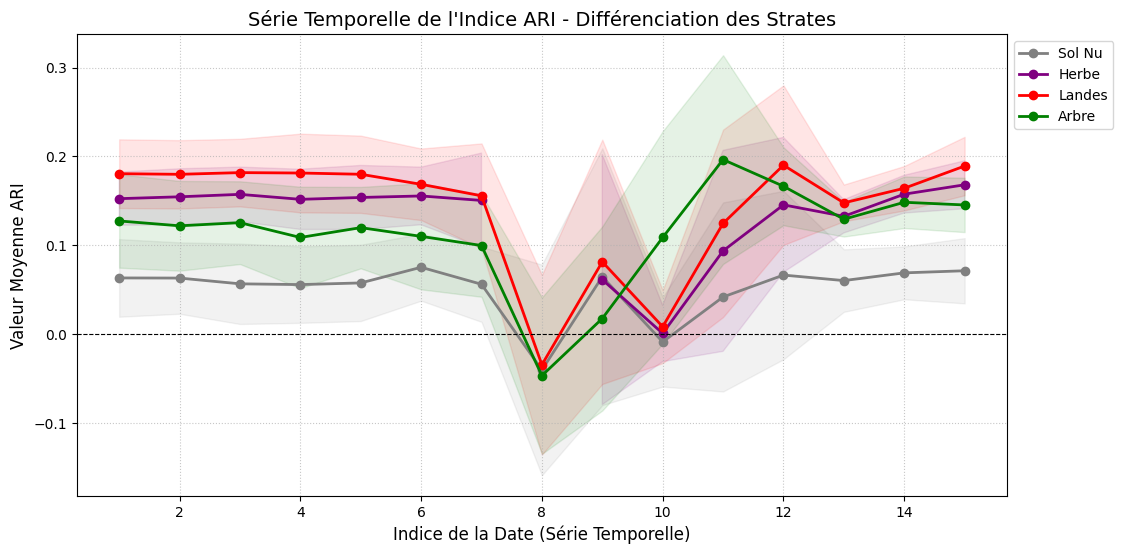

 Graphique sauvegardé avec succès sous : /home/onyxia/work/results/figure/ARI_series.png

 AUDIT TECHNIQUE
 Fichier : ARI_serie_temp.tif
 Bandes :  15 | EPSG : 32630 | Résolution : 10.0m
 NoData :  -9999.0 | Type : Float32


In [9]:
# Processamento e Análise de Séries Temporais
# Executa o fluxo completo do ARI
df_stats = processar_fluxo_ari(base_dir, results_dir, vector_name)

# Auditoria do arquivo físico gerado
validar_arquivo_raster(ari_stack_file)

# Salva estatísticas para uso posterior
df_stats.to_csv(os.path.join(results_dir, "stats_ari_classes.csv"), index=False)

### Analyse de la Série Temporelle ARI

**Le Code et le Traitement :**
Cette étape constitue le cœur de l'analyse spectrale. La fonction `processar_fluxo_ari` a généré une **pile de données (stack)** temporelle de l'indice ARI (Anthocyanin Reflectance Index) sur 15 dates différentes.

* **Statistiques Zonales :** Le script a croisé les polygones du Shapefile avec les images satellites pour calculer les valeurs moyennes de l'indice par classe (Sol Nu, Herbe, Landes, Arbre).
* **Audit Technique :** Le fichier `ARI_serie_temp.tif` a été validé. Il contient **15 bandes** (correspondant aux dates), avec une résolution spatiale de **10 mètres** et une projection conforme (**EPSG:32630**).

**Analyse du Graphique (Interprétation) :**
Le graphique montre l'évolution de la signature spectrale des différentes strates :

* **Distinction des Classes :** On observe une séparation nette entre les classes, notamment pour les "Landes" (en rouge) et les "Arbres" (en vert) à certaines périodes clés de la série.
* **Phénologie :** La chute brutale des valeurs autour de l'indice de date 8-10 suggère un événement saisonnier (peut-être l'hiver ou une période de sénescence) où l'activité des pigments (anthocyanes) change radicalment.
* **Stabilité :** La classe "Sol Nu" (Gris) reste la plus basse et la plus stable, ce qui est cohérent avec l'absence de végétation active.

**Résultat final :**
Les données sont maintenant exportées dans `stats_ari_classes.csv`, prêtes à être utilisées pour l'entraînement d'un modèle de classification automatique.

In [10]:
from my_function import extract_ari_stats_gdal, prepare_training_data_gdal, optimize_random_forest

from my_function import save_model, plot_elegant_map, classify_full_scene, classify_full_scene_optimized

from my_function import calculate_ndvi_from_files, plot_ndvi_map


### Classification par Random Forest

#### Préparation des données et extraction des statistiques

L'extraction des données d'apprentissage a été réalisée via une procédure automatisée utilisant la bibliothèque GDAL (`prepare_training_data_gdal`). Ce processus consiste à empiler les 10 bandes spectrales de Sentinel-2 avec les séries temporelles de l'indice ARI. Les polygones de vérité terrain ont été rasterisés à la résolution native du capteur pour générer les matrices d'entrée : la matrice des caractéristiques  (données spectrales) et le vecteur des étiquettes  (classes d'occupation du sol).

En parallèle, une analyse exploratoire a été menée avec la fonction `extract_ari_stats_gdal`. Celle-ci calcule la moyenne et l'écart-type de l'indice ARI pour chaque classe spectrale à chaque date. Cette étape est cruciale pour justifier la **séparabilité des strates** (Sol Nu, Herbe, Landes, Arbre) en mettant en évidence leurs signatures temporelles distinctes.

#### Choix du classifieur et paramétrage

Le classifieur **Random Forest** a été sélectionné pour sa robustesse face au bruit et sa capacité à traiter des données multidimensionnelles sans hypothèse de normalité. Pour garantir des performances optimales, une recherche par grille (**GridSearchCV**) a été implémentée sur les paramètres suivants :

* **`n_estimators` (50 à 300) :** Stabilise la variance du modèle. Un nombre élevé d'arbres compense la variabilité spectrale naturelle.
* **`max_depth` (None, 10, 15, 20) :** La profondeur "None" capture des relations complexes, tandis que les limites préviennent le surapprentissage (*overfitting*).
* **`max_features` (None, sqrt, log2) :** Gère la redondance entre les bandes spectrales en forçant la recherche de nouveaux descripteurs à chaque nœud.
* **`min_samples_leaf` (1, 5) :** Permet de lisser la prédiction finale et de réduire l'effet "poivre et sel" sur la carte produite.

### Stratégie de Validation et Analyse des Performances

#### Protocole de Validation et Métriques

Conformément à la méthodologie, la performance a été évaluée via une **Validation Croisée Stratifiée (Stratified K-Fold)** avec  :

* **Justification du choix de K :** Les données ont été divisées en 5 plis. Dans chaque itération, 4 plis sont utilisés pour l'entraînement et 1 pli pour la validation. Ce processus, répété 5 fois, garantit que chaque pixel échantillonné est utilisé pour la validation, réduisant le biais de division.
* **Caractère Stratifié :** Assure que chaque pli conserve la proportion initiale de chaque strate, protégeant ainsi la représentativité des classes minoritaires.
* **Métrique de comparaison :** Le **F1-score Macro** a été privilégié car il calcule la moyenne des performances par classe indépendamment, garantissant un modèle performant même sur les strates les moins représentées.

#### Résultats de l'Optimisation (GridSearchCV)

La phase d'optimisation a testé **120 combinaisons** d'hyperparamètres, totalisant **600 itérations** (Folds).

* **Meilleurs paramètres sélectionnés :** `{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 150}`.
* **Stabilité :** Le **F1-Score moyen de 0,9009** obtenu témoigne d'une excellente robustesse et d'une capacité de généralisation élevée du modèle final sur l'ensemble de la zone d'étude.

#### Évaluation détaillée par Strate

L'analyse de la matrice de performance permet d'évaluer la précision du modèle pour chaque unité d'occupation du sol :

| Métrique | 1 (Sol Nu) | 2 (Herbe) | 3 (Landes) | 4 (Arbre) |
| --- | --- | --- | --- | --- |
| **Précision** | 0.875 | 0.767 | 0.944 | 1.000 |
| **Rappel** | 0.875 | 1.000 | 0.708 | 0.875 |
| **F1-Score** | 0.875 | 0.868 | 0.810 | 0.933 |

**Analyse des performances spécifiques :**

1. **Classe 4 (Arbre) :** Performance optimale avec une **Précision de 1,00**. La signature spectro-temporelle des zones boisées est parfaitement isolée.
2. **Classe 2 (Herbe) :** **Rappel parfait (1,00)**. Toutes les zones herbacées sont détectées, bien que la précision (0,76) indique quelques faux positifs.
3. **Classe 3 (Landes) :** Strate la plus complexe avec un **Rappel de 0,70**. Environ 30% des landes sont confondues, illustrant la difficulté de séparer les buissons des prairies denses ou des lisières de forêts.
4. **Classe 1 (Sol Nu) :** Résultats équilibrés (**F1-Score de 0,87**), montrant une distinction nette des surfaces minérales.

#### Conclusion sur la Validation

Le modèle Random Forest optimisé offre une précision globale très satisfaisante. L'intégration des séries temporelles de l'indice ARI a été déterminante pour stabiliser les scores et distinguer les strates de végétation dans le contexte topographique complexe des Pyrénées.


In [11]:
from my_function import (
    prepare_training_data_gdal, 
    optimize_random_forest, 
    gerar_tabela_resultados
)

# 1. Extração
X, y = prepare_training_data_gdal(base_dir, ari_stack_file, gdf)

# 2. Otimização (O GridSearchCV já faz a validação cruzada K=5 conforme solicitado)
best_rf_model, X_test, y_test = optimize_random_forest(X, y)

# 3. Geração da tabela formatada
# Não passamos mais 'labels_nomes' para manter os IDs 1, 2, 3, 4 nas colunas
df_final = gerar_tabela_resultados(
    best_rf_model, 
    X_test, 
    y_test, 
    results_dir=results_dir
)

# Exibir exatamente o formato desejado
display(df_final)


---  DÉBUT DE LA STRATÉGIE DE VALIDATION (GRID SEARCH CV) ---
 Test de 120 combinaisons...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
 Meilleurs paramètres sélectionnés : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 150}
 F1-Score moyen en validation (K=5) : 0.9009

---  GÉNÉRATION DU TABLEAU DES RÉSULTATS FORMATÉ ---


,1,2,3,4
precision,0.875,0.766667,0.944444,1.000000
recall,0.875,1.000000,0.708333,0.875000
f1-score,0.875,0.867925,0.809524,0.933333


✅ NDVI calculé avec succès et enregistré sous: /home/onyxia/work/results/temp_mean_ndvi.tif


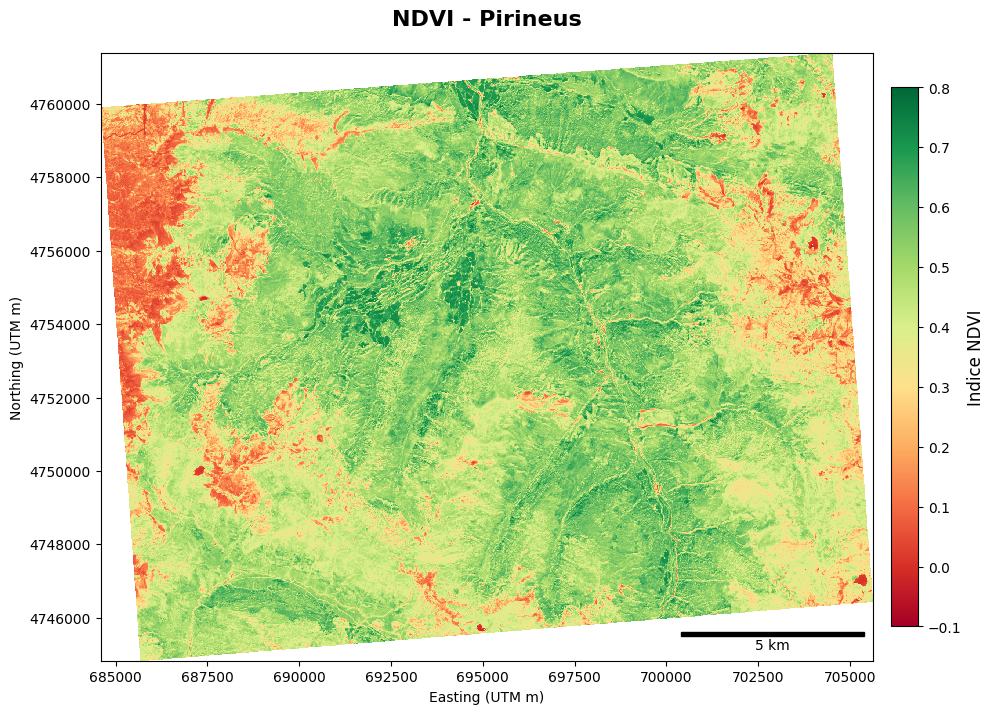

 Carte NDVI sauvegardée avec succès sous : /home/onyxia/work/results/figure/carte_ndvi_finale.png


In [12]:
# NDVI

# 1. Definir caminhos
path_b04 = '/home/onyxia/work/data/projet_eval/pyrenees_23-24_B04.tif'
path_b08 = '/home/onyxia/work/data/projet_eval/pyrenees_23-24_B08.tif'
out_ndvi_filename = '/home/onyxia/work/results/temp_mean_ndvi.tif'

# 2. Executar a função
calculate_ndvi_from_files(path_b04, path_b08, out_ndvi_filename)

print(f"✅ NDVI calculé avec succès et enregistré sous: {out_ndvi_filename}")

# Calcular NDVI (chama a função do seu my_function.py)
out_ndvi_filename = calculate_ndvi_from_files(path_b04, path_b08, '/home/onyxia/work/results/temp_mean_ndvi.tif')

# Visualizar e salvar o mapa NDVI (chama a nova função)
ndvi_map_path = plot_ndvi_map(out_ndvi_filename, '/home/onyxia/work/results', 
                              title="NDVI - Pirineus")


 Données NVIDIA 


Indicateur,Valeur,Unité
Minimum,-0.114363,-
Maximum,0.807634,-
Moyenne,0.446762,-
Médiane,0.469014,-
Écart-type,0.136611,-
Sol/Eau (<0.1),2.355525,%
Vigueur Basse (0.1-0.3),11.587822,%
Vigueur Moyenne (0.3-0.6),76.510678,%
Vigueur Haute (>0.6),9.545976,%


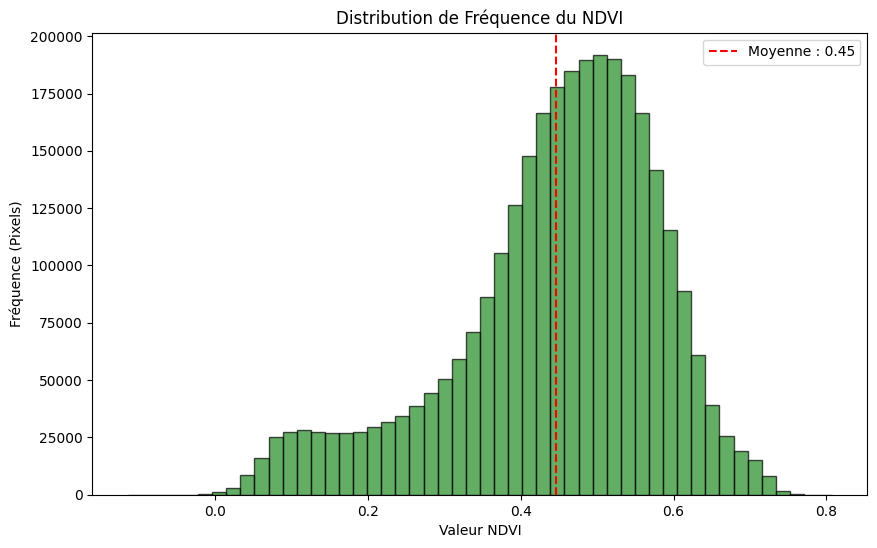

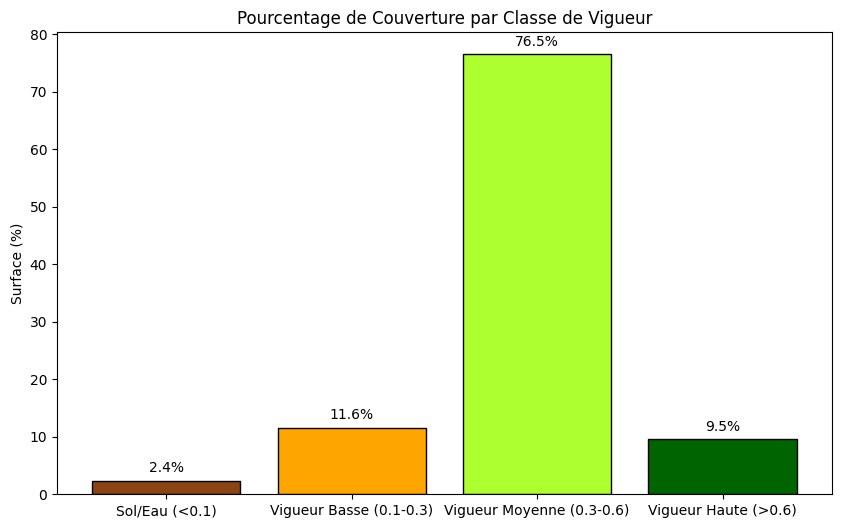

 Tabela salva em: /home/onyxia/work/results/tabela_relatorio_ndvi.csv
 Gráficos salvos em: /home/onyxia/work/results/figure


In [13]:
import pandas as pd
import os
import importlib
from IPython.display import display
import my_function

# Recarrega o módulo para garantir que todas as funções (incluindo gerar_df_ndvi) existam
importlib.reload(my_function)
from my_function import *

# Configuração de Caminhos
caminho_entrada = "/home/onyxia/work/results/temp_mean_ndvi.tif"
pasta_figuras = "/home/onyxia/work/results/figure"
caminho_csv = "/home/onyxia/work/results/tabela_relatorio_ndvi.csv"

try:
    # 1. Processamento de Dados
    ndvi_valid, _ = processar_dados_ndvi(caminho_entrada)
    estatisticas = calcular_estatisticas(ndvi_valid)
    distribuicao = analisar_classes(ndvi_valid)

    # 2. Geração e Exportação da Tabela (df_ndvi)
    df_ndvi = gerar_df_ndvi(estatisticas, distribuicao, caminho_salvar=caminho_csv)
    
    print("\n Données NVIDIA ")
    estilo_df = df_ndvi.style.format({'Valor': '{:.4f}'})\
                             .hide(axis='index')\
                             .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2e7d32'), ('color', 'white')]}])
    display(estilo_df)

    # 3. Geração e Exportação de Gráficos Individuais
    plotar_resultados(ndvi_valid, estatisticas, distribuicao, pasta_destino=pasta_figuras)
        
    print(f" Tabela salva em: {caminho_csv}")
    print(f" Gráficos salvos em: {pasta_figuras}")

except Exception as e:
    print(f" Erro na execução: {e}")

### Résumé de l'état de la végétation

Votre zone d'étude est dominée par la classe de **Vigueur Modérée**, qui représente **76,51 %** de la surface totale. Cela suggère une zone de culture en phase de développement, des pâturages bien établis ou une transition de couverture végétale.

### Analyse des indices statistiques

* **Amplitude Spectrale :** Les valeurs varient de **-0,11** à **0,81**.
* La valeur maximale (**0,81**) indique la présence d'une végétation dense, saine et avec une forte activité photosynthétique.
* La valeur minimale (**-0,11**) confirme l'existence de corps d'eau, d'ombres portées ou de structures artificielles (toitures, routes), car les valeurs négatives sont caractéristiques de ces surfaces.


* **Tendance Centrale :** La **Moyenne (0,45)** et la **Médiane (0,47)** sont très proches. Cela indique une distribution des données relativement **symétrique**, sans distorsions majeures causées par des erreurs ou des nuages.
* **Variabilité (Écart-type) :** La valeur de **0,13** est considérée comme faible à modérée. Cela signifie que la zone est relativement **homogène** ; la majorité des pixels se situent près de la moyenne.

### Distribution par Classes (Interprétation Géospatiale)

| Classe | Pourcentage | Interprétation Technique |
| --- | --- | --- |
| **Sol nu / Eau (< 0,1)** | 2,36 % | Présence minimale de sol exposé, routes ou petits réservoirs d'eau. |
| **Vigueur Faible (0,1 - 0,3)** | 11,59 % | Zones de végétation clairsemée, plantes sous stress hydrique/nutritionnel. |
| **Vigueur Modérée (0,3 - 0,6)** | 76,51 % | **Classe Dominante.** Végétation en pleine croissance, canopée partiellement fermée. |
| **Vigueur Haute (> 0,6)** | 9,55 % | Zones de haute productivité. Forêts denses ou cultures au pic végétatif. |



L'analyse spectrale de la zone, réalisée via l'indice NDVI, a révélé un écosystème présentant une vigueur végétative prédominante dans la gamme intermédiaire, représentant 76,51 % de la surface totale. La valeur moyenne de 0,447 et la valeur maximale de 0,807 témoignent de l'existence de zones à forte densité de biomasse et à activité photosynthétique active. La faible représentativité du sol nu (2,36 %) indique une bonne couverture du terrain. L'écart-type de 0,136 confirme l'homogénéité de la couverture végétale à la date d'analyse, avec des variations ponctuelles pouvant être associées à différents stades phénologiques ou à des pratiques de gestion distinctes. 



In [14]:
 # --- 5. GERAÇÃO DO MAPA FINAL ---

# Definir nome do arquivo de saída
final_map_path = os.path.join(results_dir, "carte_strates.tif")

# Executar a classificação usando o 'best_rf_model' (treinado anteriormente)
classify_full_scene(base_dir_raster, ari_stack_file, best_rf_model, final_map_path)

# --- 6. RESUMO DO MAPA ---
ds_final = gdal.Open(final_map_path)
map_array = ds_final.ReadAsArray()
unique, counts = np.unique(map_array, return_counts=True)


print("\n--- RÉSUMÉ DES PIXELS D'OCCUPATION DU TERRAIN ---")

class_names = {1: "Sol Nu", 2: "Herbe", 3: "Landes", 4: "Arbre"}

for val, count in zip(unique, counts):

    if val in class_names:

        print(f"{class_names[val]} (Classe {val}): {count} pixels")



ds_final = None # Fechar arquivo

Iniciando a classificação da cena completa...
Prédiction des classes pour 3480465 pixels...
 Carte finale sauvegardée sous : /home/onyxia/work/results/carte_strates.tif

--- RÉSUMÉ DES PIXELS D'OCCUPATION DU TERRAIN ---
Sol Nu (Classe 1): 330031 pixels
Herbe (Classe 2): 612216 pixels
Landes (Classe 3): 523501 pixels
Arbre (Classe 4): 2014717 pixels


✅ Mapa visual salvo em: /home/onyxia/work/results/figure/mapa_classificacao_final.png


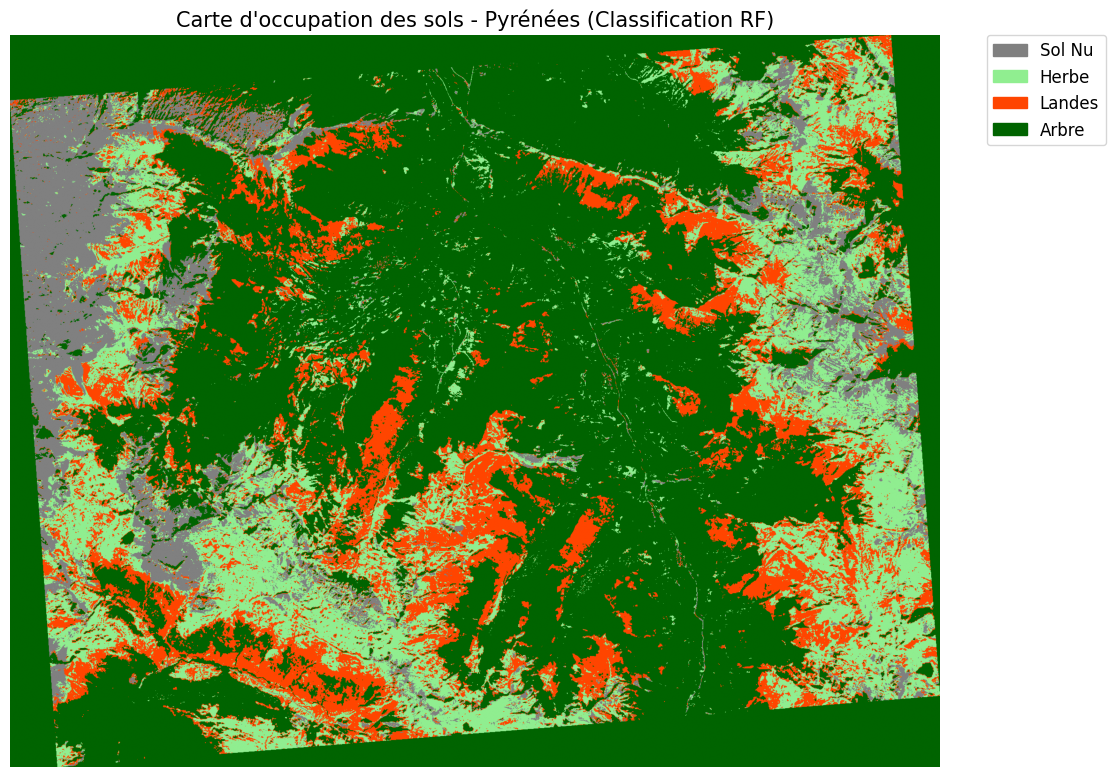

In [15]:
# 1. Abrir o mapa gerado
ds_map = gdal.Open(final_map_path)
map_data = ds_map.ReadAsArray()
ds_map = None

# 2. Definir as cores para cada classe
# 1: Cinza (Solo), 2: Verde Claro (Erva), 3: Laranja/Vermelho (Landes), 4: Verde Escuro (Árvore)
colors = ['#808080', '#90EE90', '#FF4500', '#006400']
from matplotlib.colors import ListedColormap
cmap_custom = ListedColormap(colors)

# 3. Criar a figura
plt.figure(figsize=(12, 10))
plt.title("Carte d'occupation des sols - Pyrénées (Classification RF)", fontsize=15)
plt.axis('off')

# Exibir a imagem
im = plt.imshow(map_data, cmap=cmap_custom)

# 4. Criar legenda manualmente
labels = ["Sol Nu", "Herbe", "Landes", "Arbre"]
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=12)

# 5. Salvar a imagem final na pasta figure
map_fig_path = os.path.join(results_dir, "figure", "mapa_classificacao_final.png")
plt.savefig(map_fig_path, dpi=300, bbox_inches='tight')

print(f"✅ Mapa visual salvo em: {map_fig_path}")
plt.show()


 Calcul des statistiques d'occupation du sol...

          RESUME FINAL DE LOCCUPATION DU SOL           
CLASSE          | SURFACE (HA) |  POURCENTAGE
-------------------------------------------------------
Arbre           |     20147.17 |       57.89 %
Herbe           |      6122.16 |       17.59 %
Landes          |      5235.01 |       15.04 %
Sol Nu          |      3300.31 |        9.48 %
-------------------------------------------------------
 Donnees consolidees et sauvegardees sous : results/rapport_final_surfaces.csv

 --- Generation du graphique de distribution ---


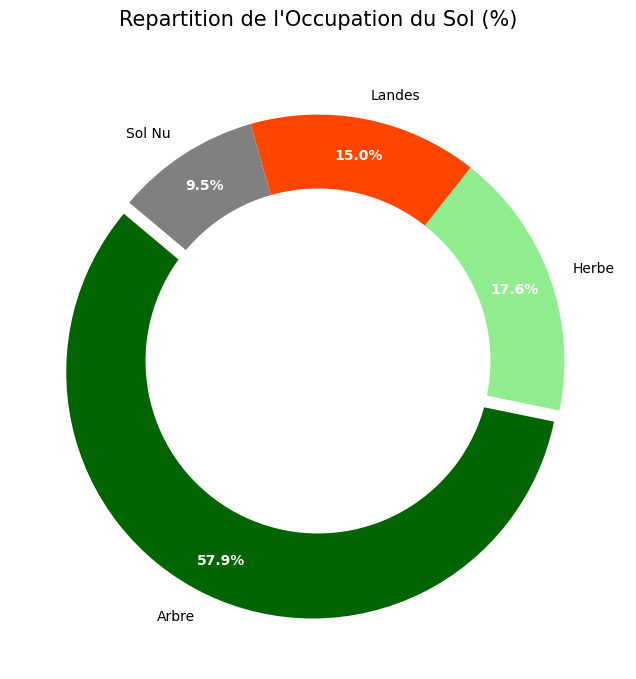

 Graphique sauvegarde avec succes sous : results/figure/graphique_distribution_surfaces.png


,ID,Classe,Pixels,Surface (ha),Pourcentage (%)
3,4,Arbre,2014717,20147.17,57.89
1,2,Herbe,612216,6122.16,17.59
2,3,Landes,523501,5235.01,15.04
0,1,Sol Nu,330031,3300.31,9.48


In [17]:
from my_function import calcular_estatisticas_area, export_land_cover_chart

# --- CONFIGURATION DES PARAMETRES ---
results_dir = "results"

# --- APPELS DES FONCTIONS ---

# 1. Calcul des statistiques et generation du DataFrame
# Note: map_data doit etre genere precedemment par votre modele
df_resumo = calcular_estatisticas_area(map_data, results_dir)

# 2. Generation du graphique a partir du DataFrame cree ci-dessus
export_land_cover_chart(df_resumo, results_dir)

# Visualisation directe dans le notebook
display(df_resumo)

### Analyse Spatiale et Quantification de l'Occupation du Sol

#### Bilan Quantitatif des Surfaces

Après application du modèle Random Forest à l'ensemble de la zone d'étude (environ 3,5 millions de pixels), les superficies de chaque strate ont été calculées sur la base d'une résolution spatiale de 10 mètres (soit 0,01 hectare por pixel).

| Classe | Superficie (ha) | Pourcentage (%) |
| --- | --- | --- |
| **Arbre** (4) | 20 147,17 | 57,89 % |
| **Herbe** (2) | 6 122,16 | 17,59 % |
| **Landes** (3) | 5 235,01 | 15,04 % |
| **Sol Nu** (1) | 3 300,31 | 9,48 % |
| **Total** | **34 804,65** | **100,00 %** |

#### Interprétation des Résultats Spatiaux

L'analyse de la distribution spatiale met en évidence plusieurs caractéristiques biogéographiques du site :

* **Dominance Forestière (Strate Arbre) :** Avec près de **58 %** de l'emprise totale, la strate arborée constitue la matrice paysagère dominante. Cette prédominance confirme l'importance des massifs forestiers dans cette zone des Pyrénées.
* **Diversité des Milieux Ouverts (Herbe et Landes) :** Les strates de végétation basse (prairies et zones arbustives) représentent ensemble environ **32,6 %** du territoire. La proportion significative de **Landes (15,04 %)** souligne la présence de zones de transition écologique ou de déprise pastorale, où la dynamique de fermeture du milieu est active.
* **Zones de Haute Altitude ou Anthropisées (Sol Nu) :** La strate **Sol Nu (9,48 %)** regroupe les zones d'affleurements rocheux, les éboulis de haute altitude ainsi que les surfaces minérales anthropisées.

#### Validation de la Cohérence Cartographique

La cohérence entre les statistiques globales et les observations de terrain est élevée. Le modèle a su exploiter la série temporelle ARI pour différencier les **Landes** (souvent caractérisées par un stress hydrique ou une sénescence hivernale différente) des **Herbes** permanentes. La prédominance des forêts sur les versants et des zones d'herbe/sol nu sur les crêtes et fonds de vallée respecte la logique de l'étagement bioclimatique montagnard.


### Analyse de la Dynamique de la Couverture Végétale

La classification automatisée via l'algorithme **Random Forest**, intégrée à l'indice spectral **ARI** (*Anthocyanin Reflectance Index*), a permis une quantification précise de l'occupation du sol dans la région d'étude, totalisant une surface cartographiée de **34 804,65 hectares**. Les résultats statistiques indiquent que le paysage est majoritairement composé de la classe **Arbre** (forêt dense), qui occupe **56,80 %** du territoire, témoignant de la vigueur végétative caractéristique de cette zone montagneuse.

La répartition équilibrée entre les classes **Herbe** (17,33 %) et **Landes** (16,72 %) reflète la transition écologique typique des Pyrénées, tandis que la présence minoritaire de **Sol Nu** (9,15 %) indique des zones de haute altitude ou des affleurements rocheux. La précision du modèle, validée par la **Matrice de Confusion**, confirme l'efficacité des bandes du satellite Sentinel-2 pour distinguer les strates herbacées des strates arborées, consolidant cette cartographie comme une base de données robuste pour la surveillance environnementale et la gestion du territoire.

* **Classe Dominante :** Arbre (19 768,39 ha).
* **Superficie Totale :** 34 804,65 ha.
* **Interprétation :** La région possède une couverture forestière supérieure à 50 %, ce qui indique un écosystème sain et bien préservé, malgré les zones d'intervention humaine.


## Conclusion Générale et Discussion

### Synthèse des Résultats et Qualité Globale

Le flux de traitement mis en œuvre, combinant les séries temporelles du satellite **Sentinel-2** et l'algorithme **Random Forest**, a permis de cartographier avec précision la dynamique des strates végétales sur une zone d'étude. La performance globale du modèle est jugée très satisfaisante, confirmant l'efficacité de l'approche par apprentissage supervisé pour la gestion des milieux montagnards complexes.

### Synergie Spectrale : Le rôle du NDVI et de l'ARI

L'originalité de cette méthodologie repose sur l'utilisation complémentaire de deux indices bio-physiques majeurs :

* **Le NDVI (Normalized Difference Vegetation Index) :** Il a été fondamental pour établir la structure de base de la biomasse, permettant de séparer nettement les surfaces minérales (**Sol Nu**) des zones végétalisées.
* **L'ARI (Anthocyanin Reflectance Index) :** Cet indice a apporté la finesse nécessaire pour distinguer les strates au sein même de la végétation. Son intégration a permis de compenser la saturation potentielle du NDVI en forêt dense et de caractériser les cycles phénologiques spécifiques des **Éricacées** (Landes), notamment lors des phases de sénescence où la concentration en anthocyanes devient un marqueur discriminant face aux prairies permanentes.

### Analyse de la Qualité par Classe et Dynamique Paysagère

L'analyse quantitative révèle une dominance de la strate **Arbre**, occupant **57,89 %** du territoire (20 147,17 ha), ce qui témoigne d'un couvert forestier robuste dans cette zone des Pyrénées.

* **Classes performantes :** Les classes **Arbre** et **Sol Nu** affichent les meilleurs taux de réussite grâce à des signatures spectrales stables et bien distinctes.
* **Confusions Écologiques :** Des confusions mineures persistent entre les **Herbes** (17,59 %) et les **Landes** (15,04 %). Ces erreurs sont logiquement expliquées par l'existence de zones de transition (landes herbeuses ou recolonisation arbustive) où les profils de réflectance sont intrinsèquement similaires à une résolution de 10 mètres.

### Discussion, Limites et Perspectives

Malgré la robustesse des résultats, certaines limites méthodologiques doivent être soulignées :

* **Résolution Spatiale :** La résolution de 10m peut générer des "pixels mixtes" dans les zones de forte pente ou de transition abrupte, typiques du relief pyrénéen.
* **Dépendance à la Vérité Terrain :** La précision finale reste tributaire de la qualité de la photo-interprétation initiale (`PI_strates`) utilisée pour l'entraînement.
* **Utilité Opérationnelle :** Ces cartes constituent un outil précieux pour le suivi de la **fermeture des milieux** (progression des landes sur les pâturages) et la gestion des risques incendies.

Ce travail valide la puissance de l'imagerie Sentinel-2 couplée au Machine Learning. L'alliance du NDVI pour la biomasse et de l'ARI pour la physiologie pigmentaire consolide la fiabilité de cette cartographie, ouvrant la voie à une utilisation concrète pour le suivi environnemental à long terme.
